In [69]:
import os
from typing import NamedTuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



class SeriesConfig(NamedTuple):
    x: np.ndarray
    y: np.ndarray
    label: str
    color: str

In [70]:
def removeFileEuropenComma(filePath: str, outputPath: str) -> None:
    with open(filePath, "r", encoding="utf-8") as fIn:
        with open(outputPath, "w", encoding="utf-8") as fOut:
            for line in fIn:
                fOut.write(line.replace(",", "."))



def getDataset(basePath: str) -> np.ndarray:
  tempfile = "temp.csv"
  dataset = None
  tempFileCreated = False

  for dataFile in os.listdir(basePath):
      filePath = os.path.join(basePath, dataFile)

      with open(filePath, "r", encoding="utf-8") as fIn:
          firstLine = fIn.readline()

      if ";" in firstLine:
          removeFileEuropenComma(filePath, tempfile)
          dataPath = tempfile
          delimiter = ";"
          tempFileCreated = True
      else:
          dataPath = filePath
          delimiter = ","

      dataset = np.genfromtxt(dataPath, delimiter=delimiter, skip_header=1)

  if tempFileCreated:
      os.remove(tempfile)

  return dataset

In [71]:
sns.set_theme(style="white")  # plot style

plt.rcParams.update({
    "font.size":         8,
    "font.family":       "DejaVu Sans",
    "font.sans-serif":   ["Alegreya Sans", "Alegreya"],
    "figure.autolayout": True,
    "figure.dpi":        300,
    "figure.figsize":    (12, 6), # wymiary wykresu
    "xtick.color":       "black",
})

sns.set_palette([
    "#525174",
    "#EC7357",
    "#6DA34D",
    "#2D93AD",
    "#A3A6F1",
    "#B5566A", 
    "#FEC601",
])


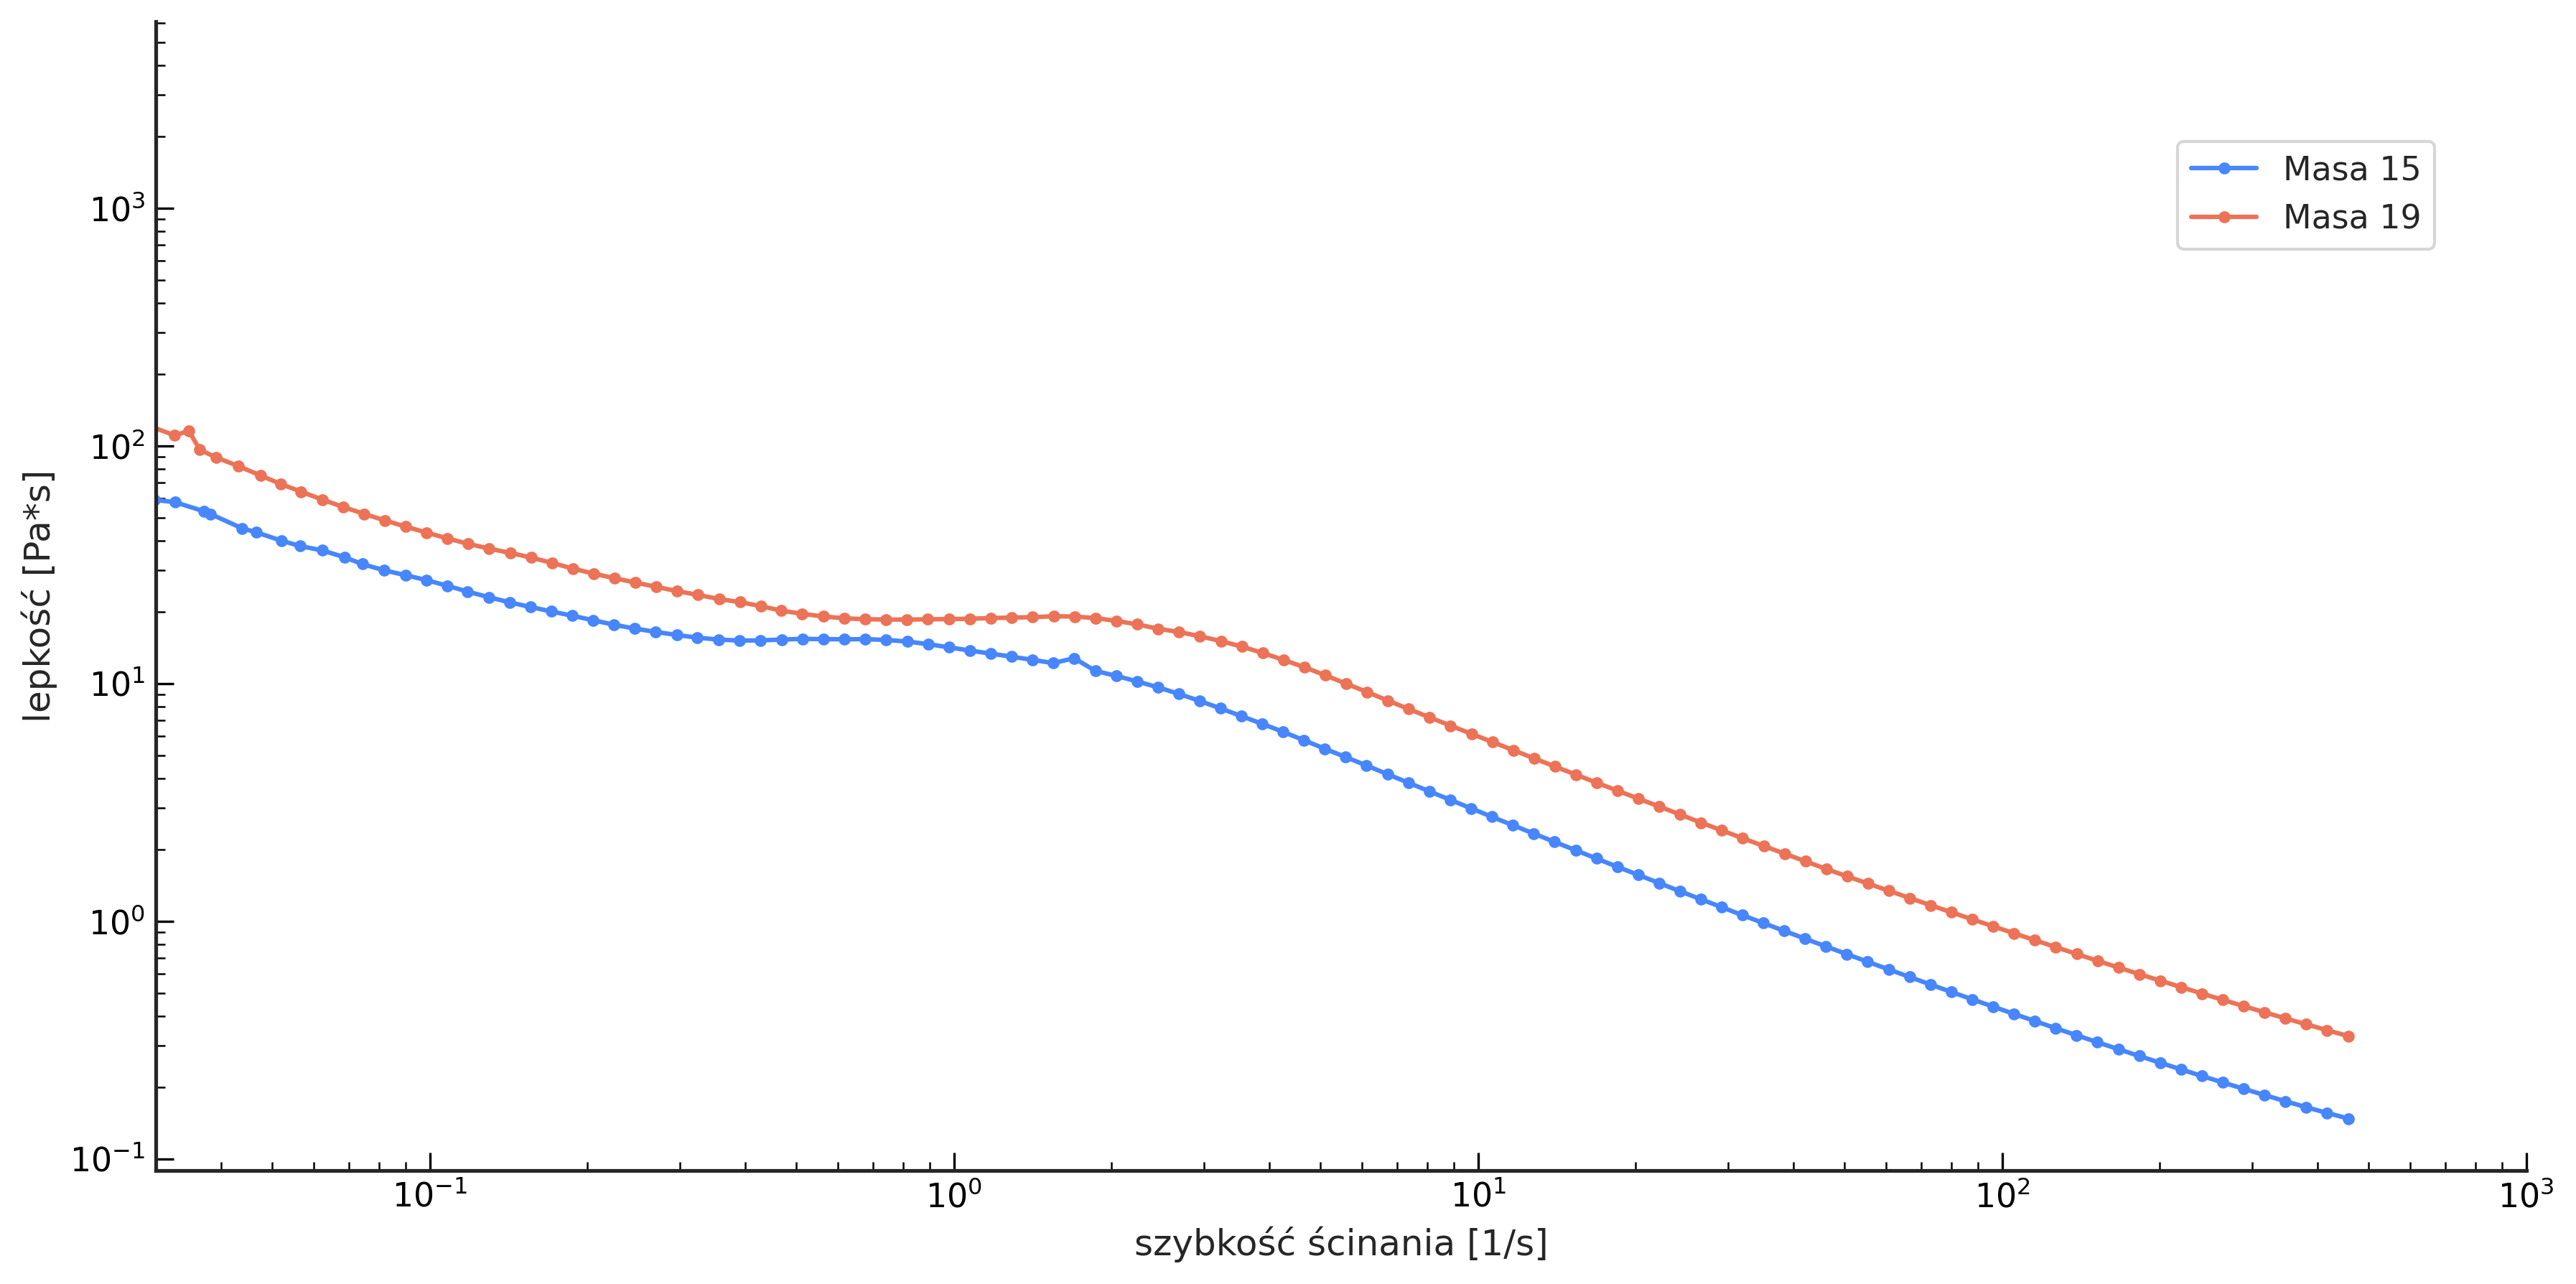

In [72]:
from matplotlib.ticker import LogLocator

def plotDataset(
    series1: SeriesConfig,
    series2: SeriesConfig,
    *,
    x_limits: tuple[float, float] | None = None,
    y_limits: tuple[float, float] | None = None,
 ) -> None:
  order1 = np.argsort(series1.x)
  order2 = np.argsort(series2.x)

  x1 = series1.x[order1]
  y1 = series1.y[order1]
  x2 = series2.x[order2]
  y2 = series2.y[order2]

  #stworzenie dwoch osi - os_lewo i os_prawo
  fig, os_lewo = plt.subplots()

  # seria danych 1
  line1 = os_lewo.plot(x1, y1, color=series1.color, label=series1.label, marker=".", markersize=6)
  # seria danych 2
  line2 = os_lewo.plot(x2, y2, color=series2.color, label=series2.label, marker=".", markersize=6)

  ## inne własności wykresu
  os_lewo.set_xscale('log')
  os_lewo.set_yscale('log')

  if x_limits is not None:
    os_lewo.set_xlim(x_limits[0], x_limits[1]) # limity x
  if y_limits is not None:
    os_lewo.set_ylim(y_limits[0], y_limits[1]) # limity osi lewej

  os_lewo.set_ylabel('lepkość [Pa*s]')
  os_lewo.set_xlabel("szybkość ścinania [1/s]")

  #plt.title("Wykres TG i DTA w funkcji temperatury")


  # drobne ticki
   # Tick ustawienia: większe kreski dla major, małe dla minor
  os_lewo.tick_params(axis='x', which='major', length=6, width=0.8, direction='in', colors='black')
  os_lewo.tick_params(axis='x', which='minor', length=3, width=0.6, direction='in', colors='black')
  os_lewo.tick_params(axis='y', which='major', length=6, width=0.8, direction='in', colors='black')
  os_lewo.tick_params(axis='y', which='minor', length=3, width=0.6, direction='in', colors='black')

  os_lewo.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
  os_lewo.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
  os_lewo.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
  os_lewo.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))


  # bez gornej i prawej ramki
  os_lewo.spines['top'].set_visible(False)
  os_lewo.spines['right'].set_visible(False)
  os_lewo.tick_params(top=False, right=False)

  # tylko dolna i lewa oś
  os_lewo.xaxis.set_ticks_position('bottom')
  os_lewo.yaxis.set_ticks_position('left')


  # hack na legende dla obu osi
  lines = line1 + line2
  labels = [l.get_label() for l in lines]
  fig.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.9))

  plt.show()

path = "../datasets2/wykres_15_19"
dataset = getDataset(path)
series1 = SeriesConfig(dataset[:, 0], dataset[:, 1], 'Masa 15', "#4786FC")
series2 = SeriesConfig(dataset[:, 2], dataset[:, 3], 'Masa 19', '#EC7357')
plotDataset(series1, series2, x_limits=(3e-2, 1e3))


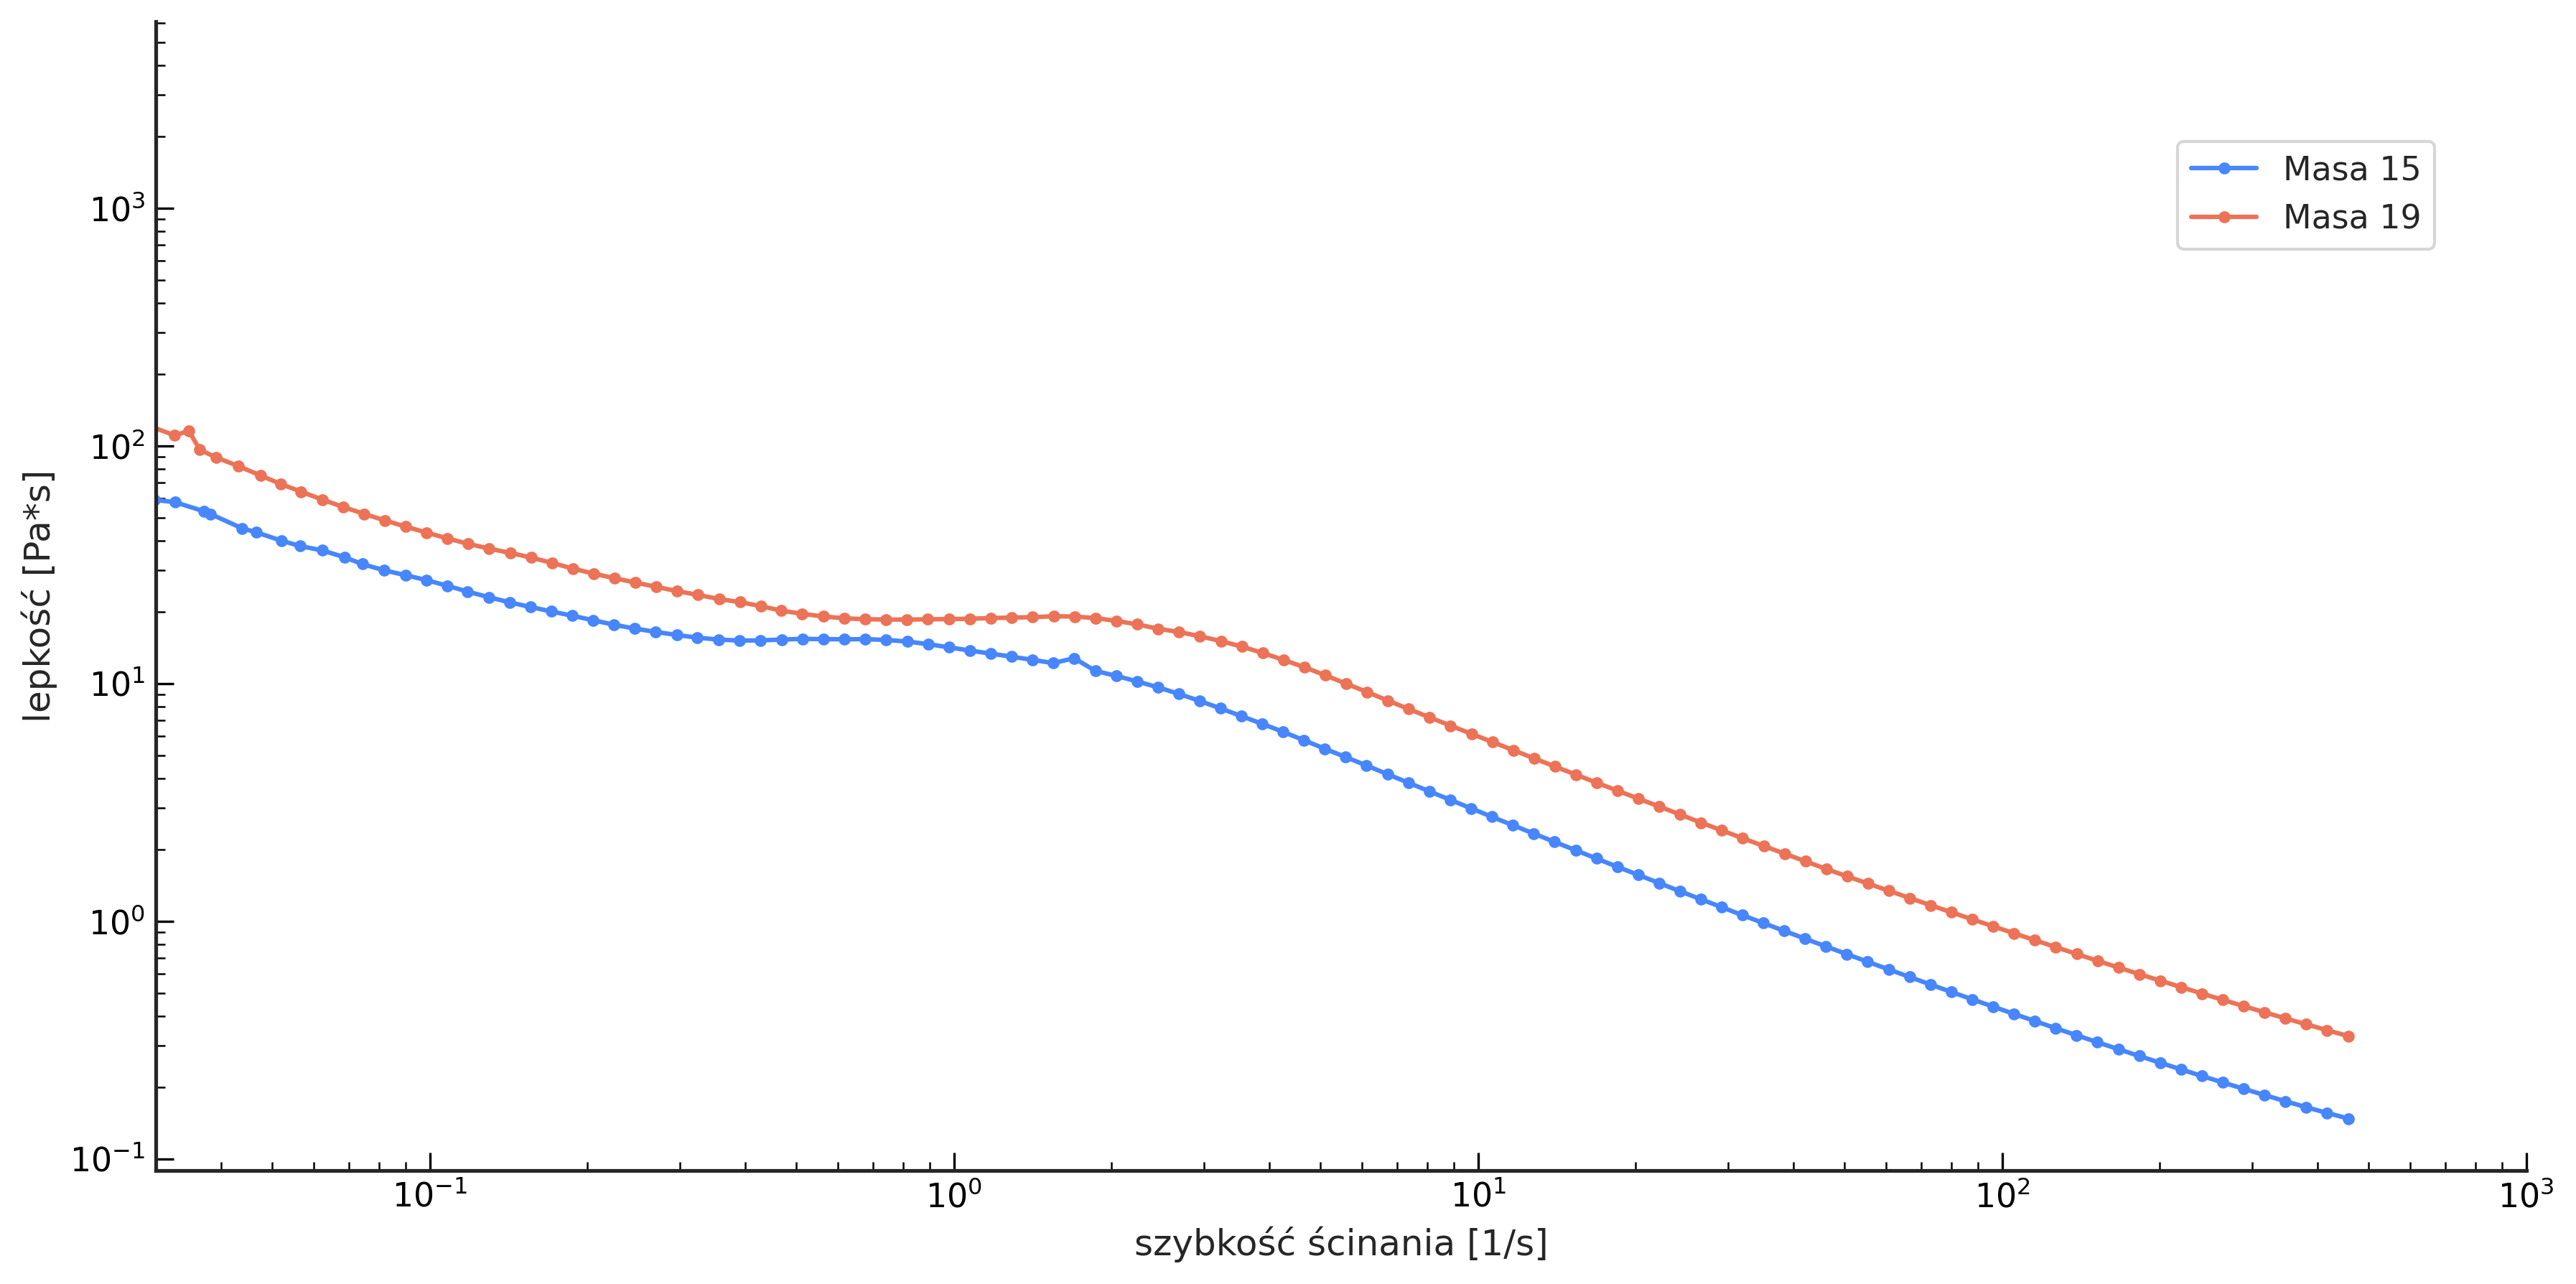

In [73]:
path = "../datasets2/wykres_15_19"
dataset = getDataset(path)
series1 = SeriesConfig(dataset[:, 0], dataset[:, 1], 'Masa 15', "#4786FC")
series2 = SeriesConfig(dataset[:, 2], dataset[:, 3], 'Masa 19', '#EC7357')
plotDataset(series1, series2, x_limits=(3e-2, 1e3))

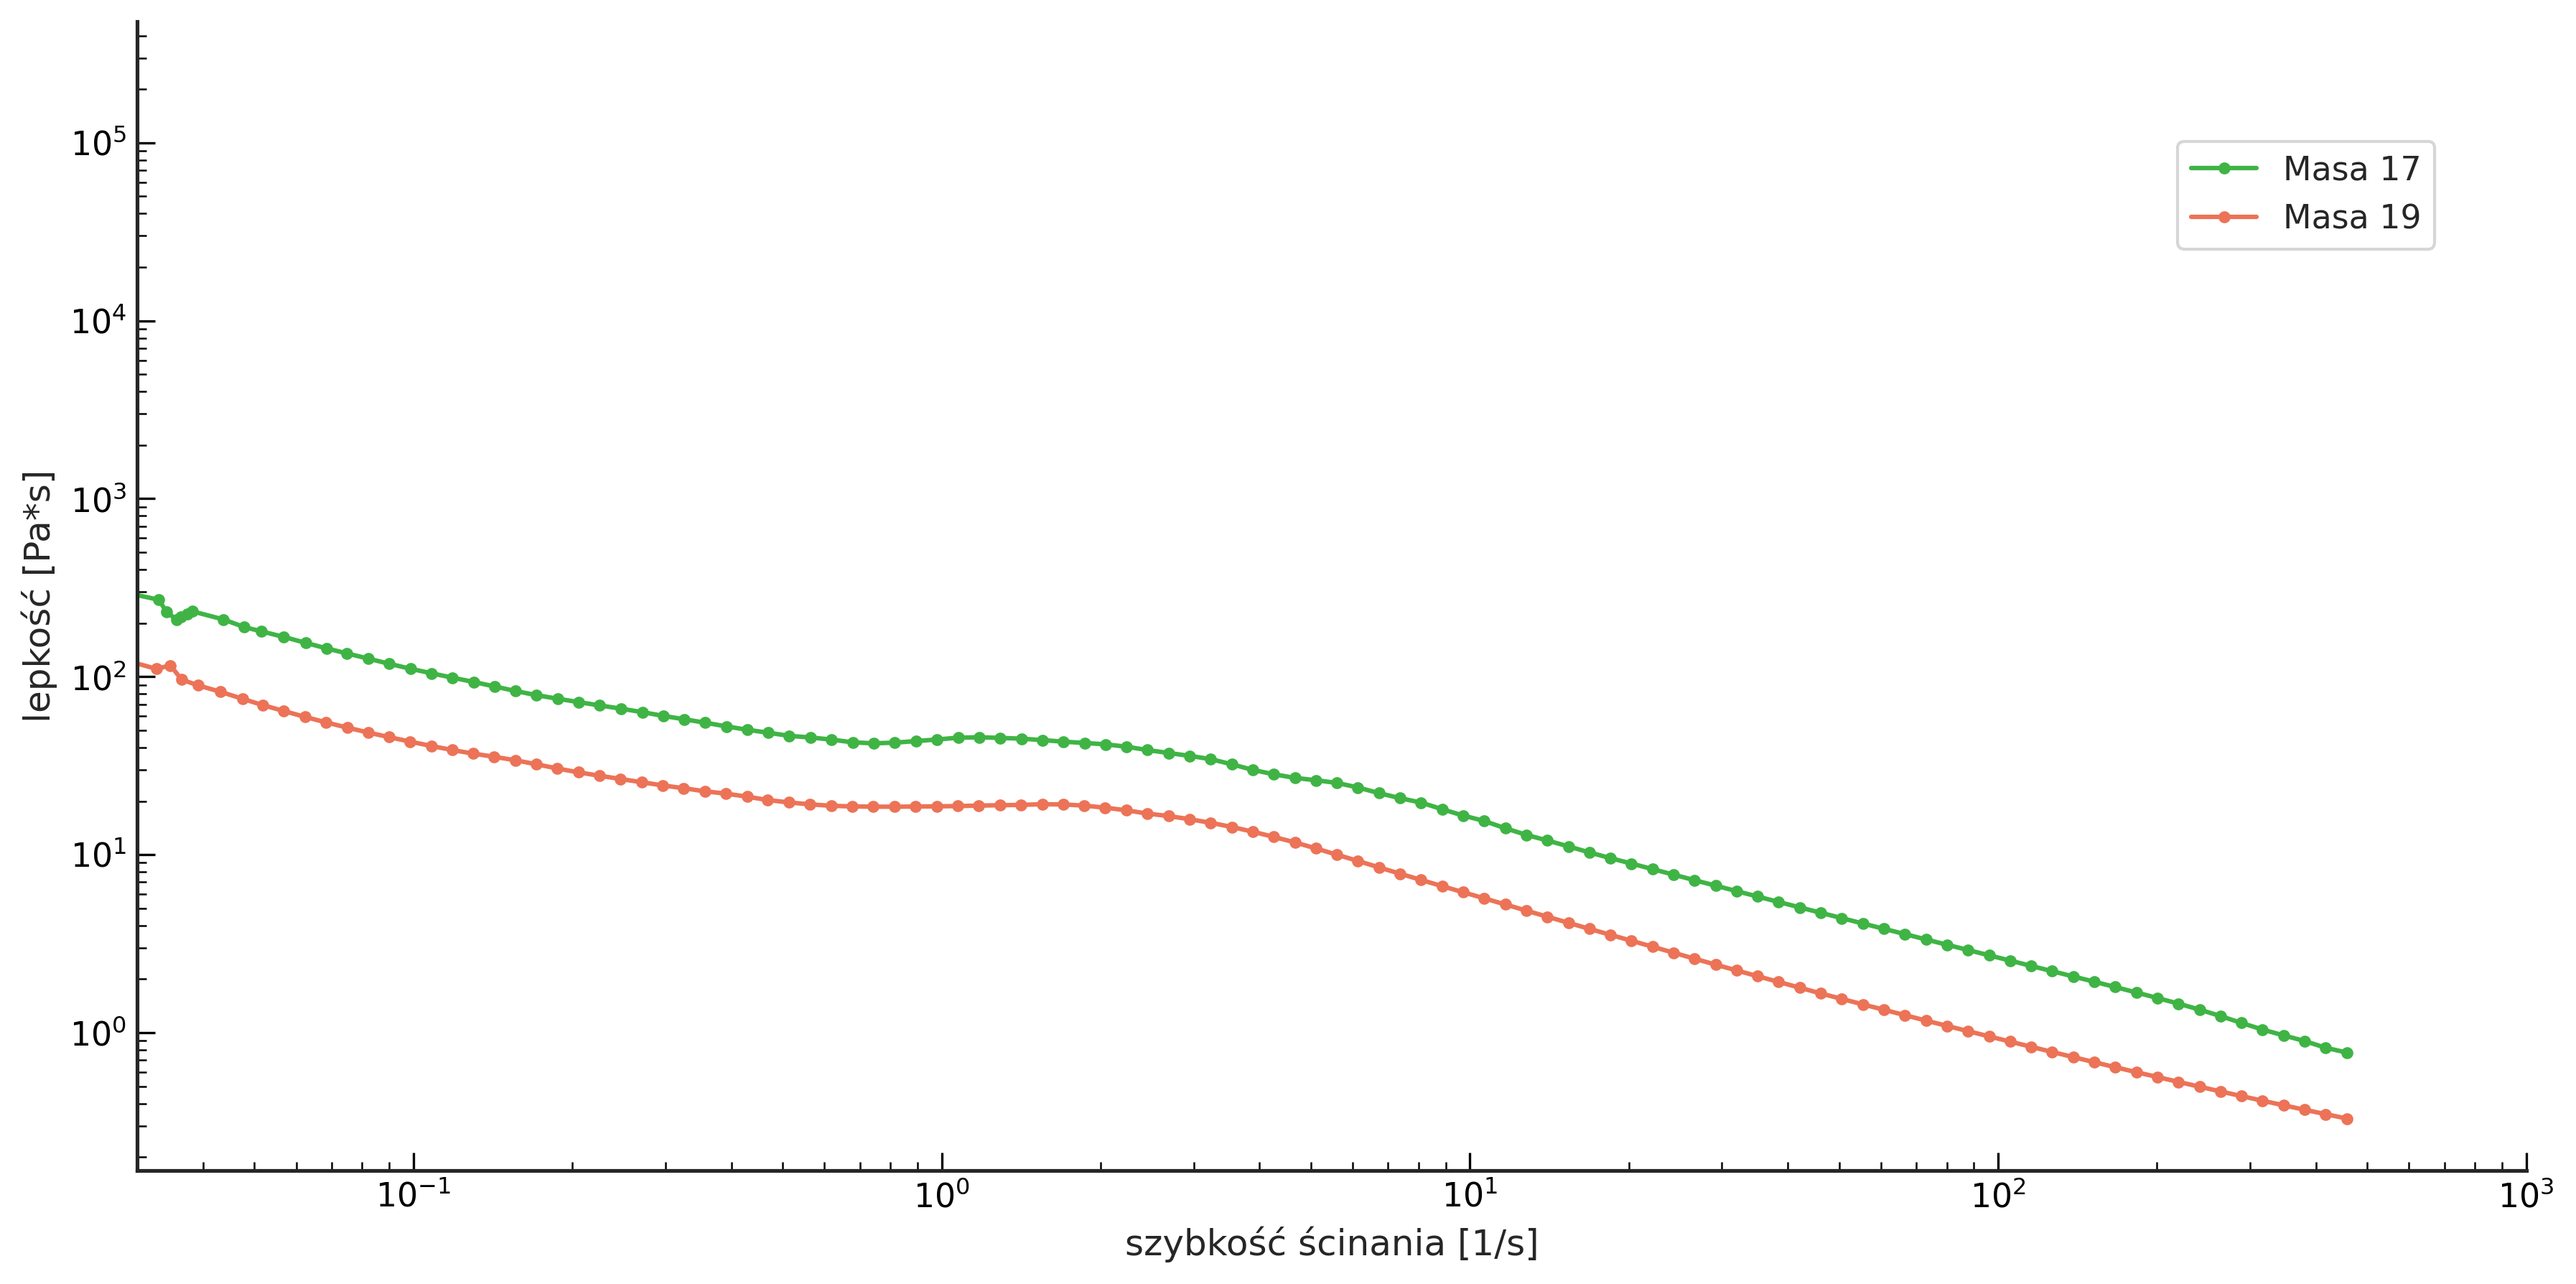

In [74]:
path = "../datasets2/wykres_17_19"
dataset = getDataset(path)
series1 = SeriesConfig(dataset[:, 0], dataset[:, 1], 'Masa 17', "#3FB445")
series2 = SeriesConfig(dataset[:, 2], dataset[:, 3], 'Masa 19', '#EC7357')
plotDataset(series1, series2, x_limits=(3e-2, 1e3))


C:\Users\kucin\AppData\Local\Temp\ipykernel_26812\2179439542.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  os_lewo.set_ylim(y_limits[0], y_limits[1]) # limity osi lewej


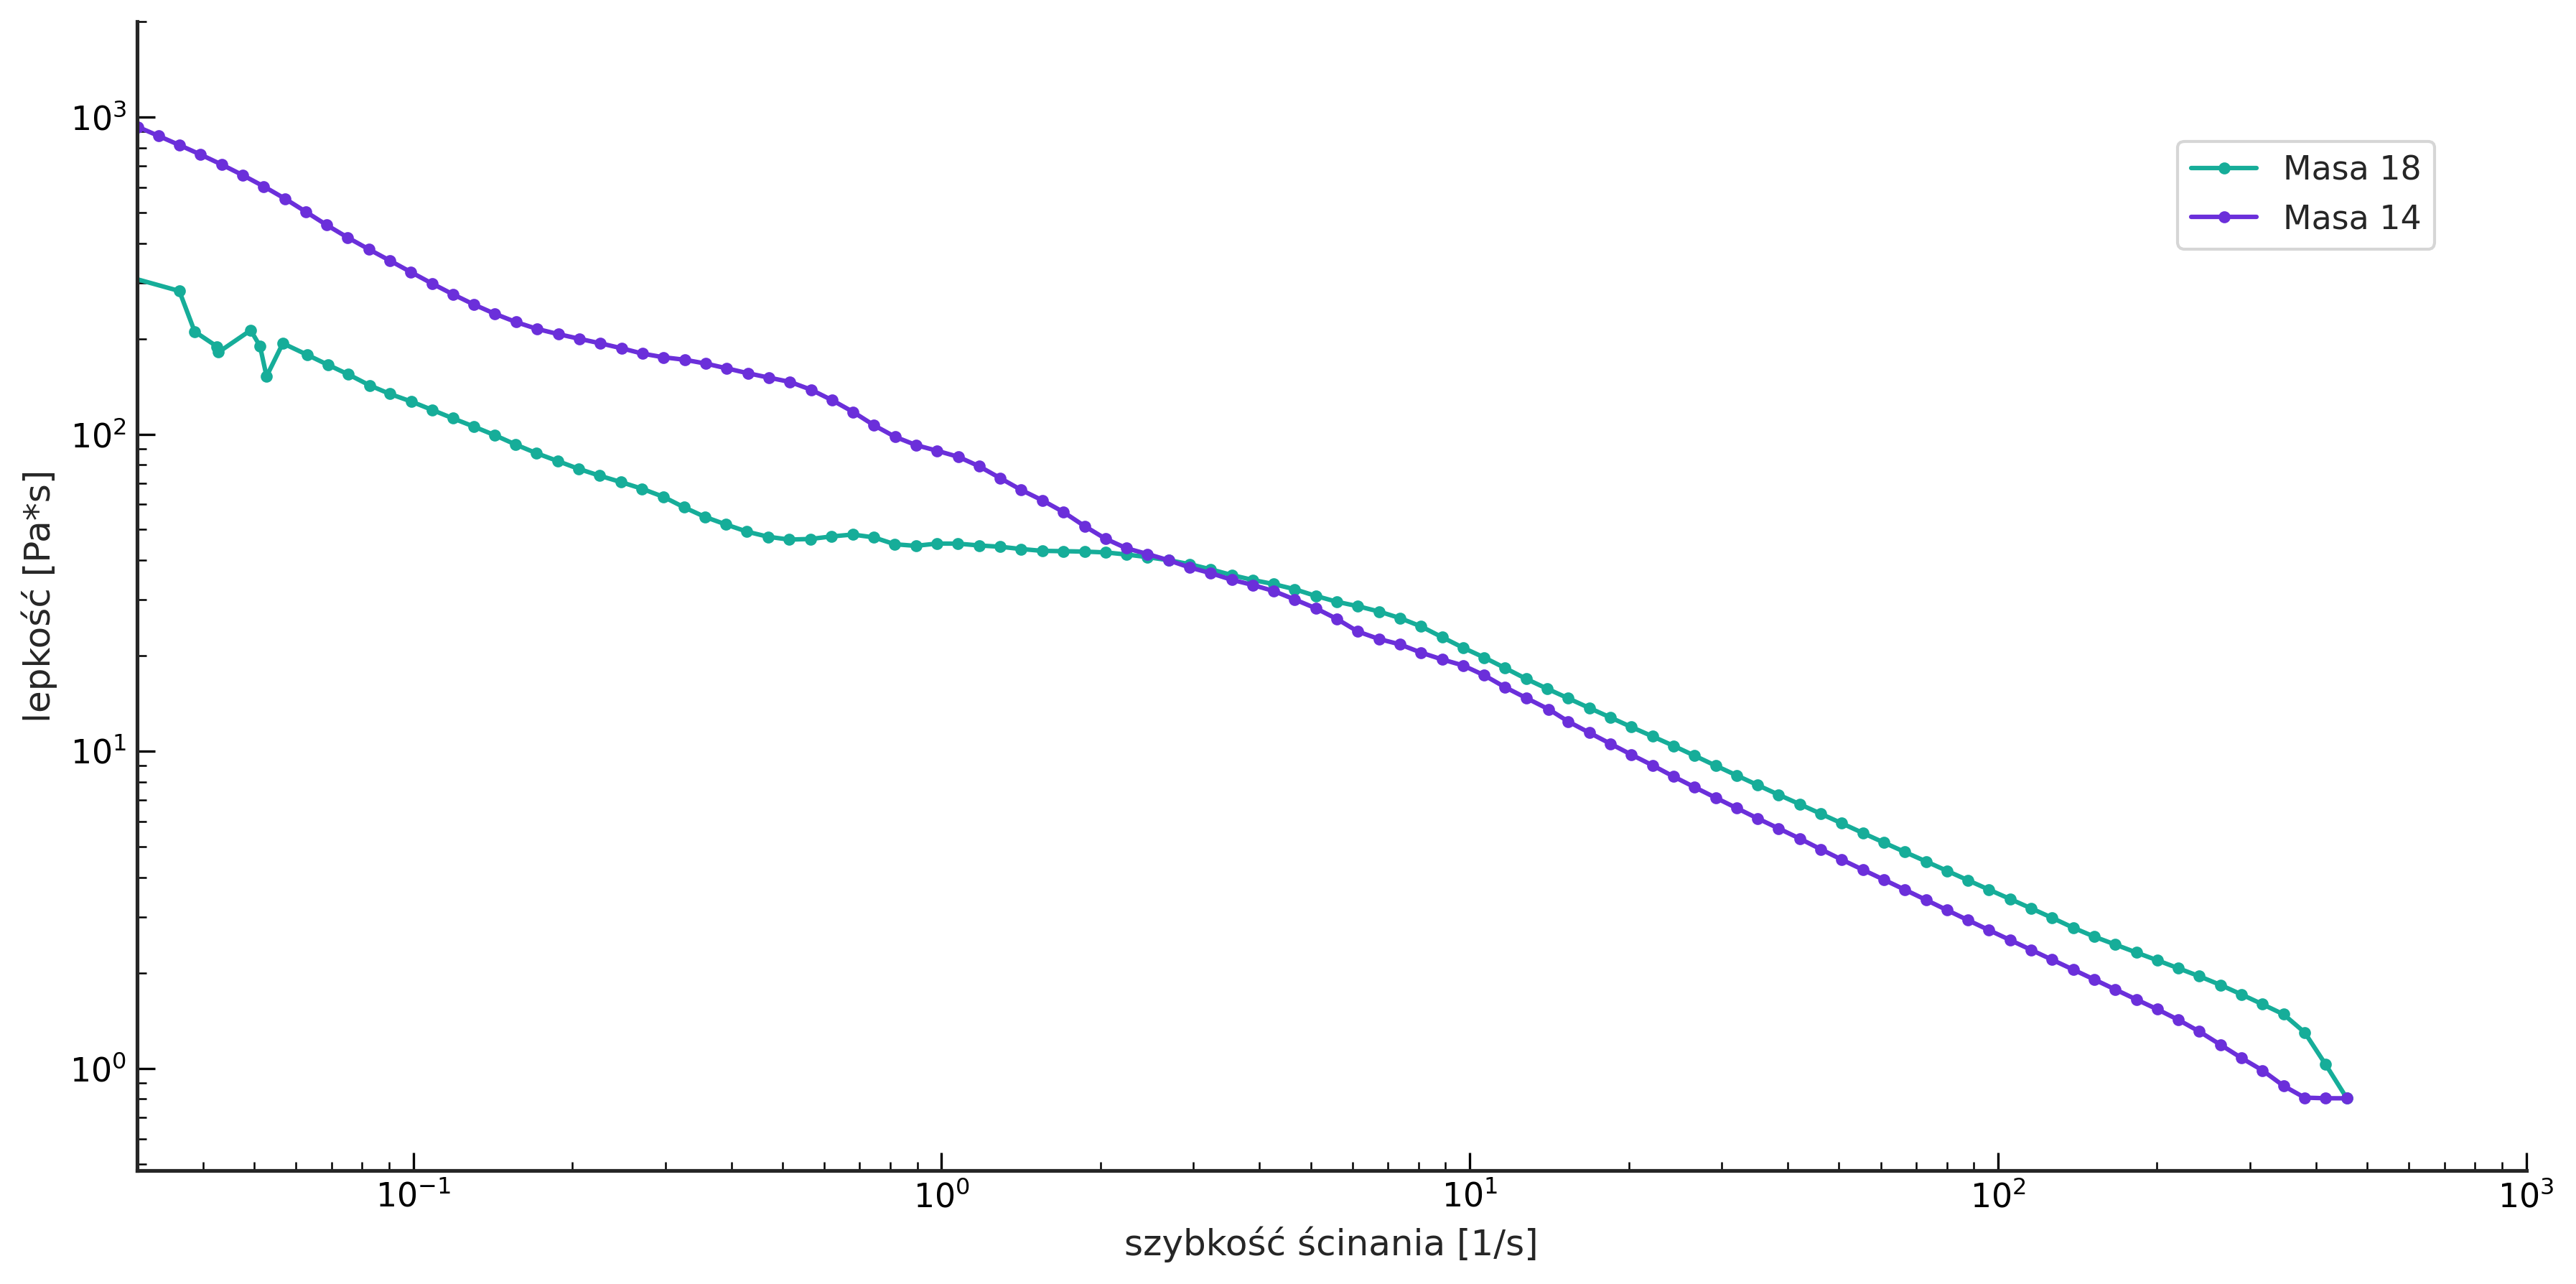

In [75]:

path = "../datasets2/wykres_18_14"
dataset = getDataset(path)
series1 = SeriesConfig(dataset[:, 0], dataset[:, 1], 'Masa 18', "#16AD99")
series2 = SeriesConfig(dataset[:, 2], dataset[:, 3], 'Masa 14', "#6B2FDA")
plotDataset(series1, series2, x_limits=(3e-2, 1e3), y_limits=(0, 2e3))

C:\Users\kucin\AppData\Local\Temp\ipykernel_26812\2179439542.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  os_lewo.set_ylim(y_limits[0], y_limits[1]) # limity osi lewej


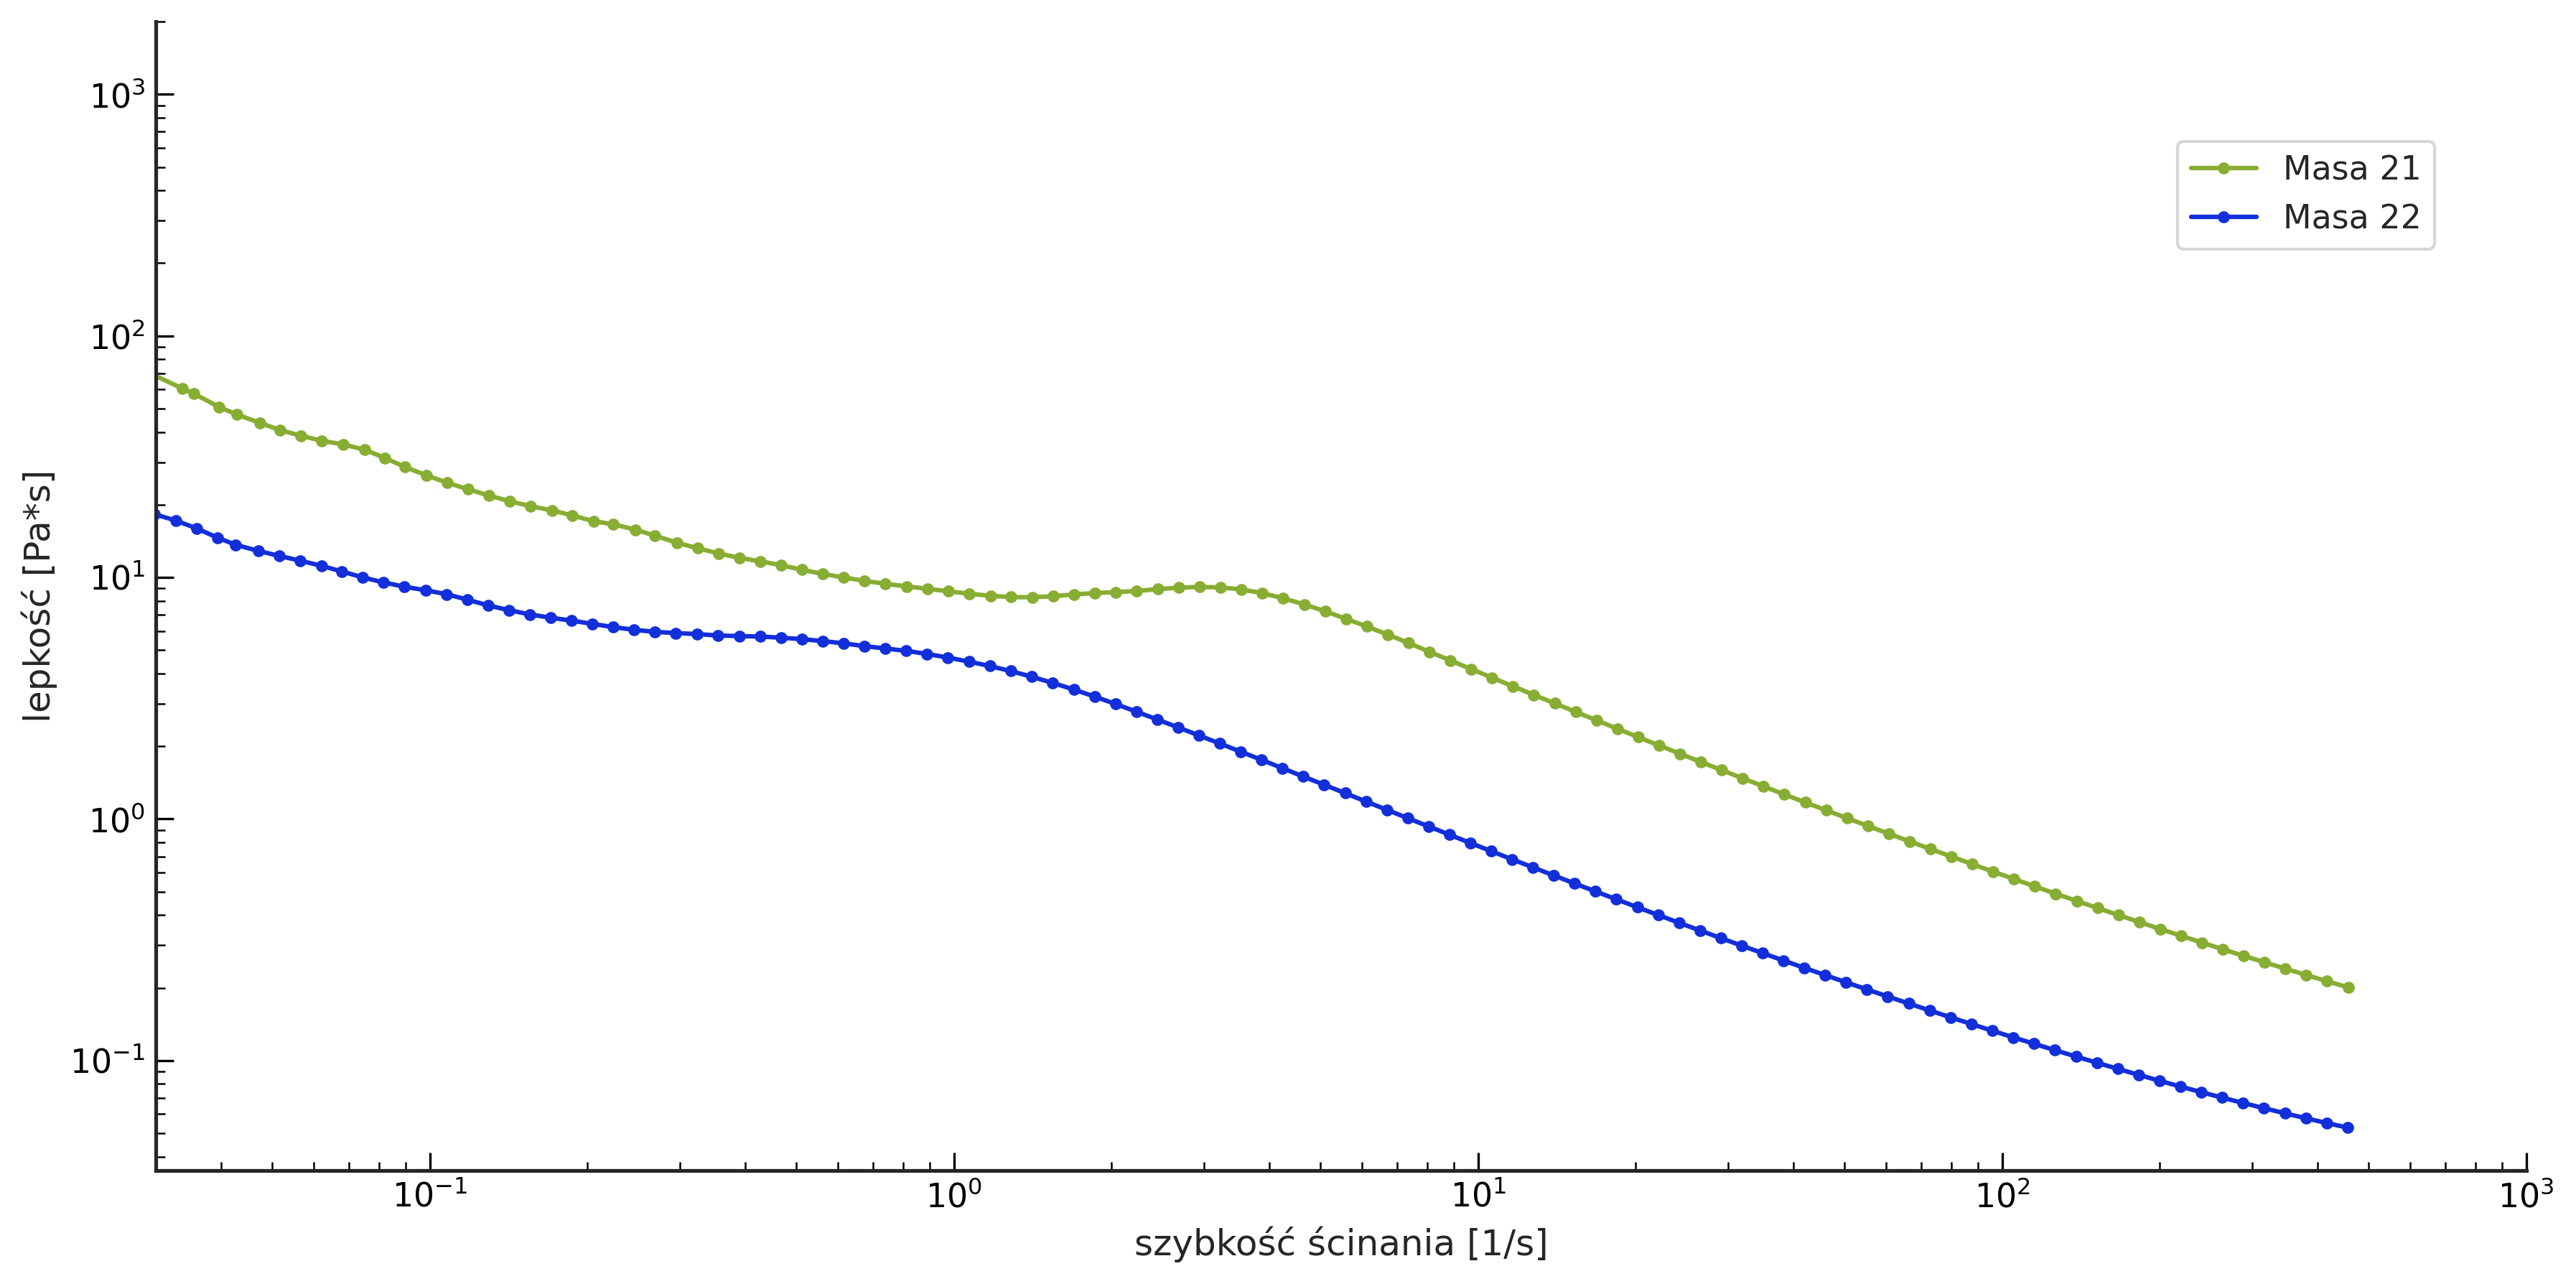

In [78]:

path = "../datasets2/wykres_21_22"
dataset = getDataset(path)
series1 = SeriesConfig(dataset[:, 0], dataset[:, 1], 'Masa 21', "#88AD33")
series2 = SeriesConfig(dataset[:, 2], dataset[:, 3], 'Masa 22', "#122FDA")
plotDataset(series1, series2,  x_limits=(3e-2, 1e3), y_limits=(0, 2e3))